J-1. Verifikasi lingkungan kerja

In [2]:
import sys, platform, multiprocessing

print("Phyton   :", sys.version.split()[0])
print("OS       :", platform.platform())
print("CPU.core :", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
  try:
    mod = __import__(nama)
    print(f"{nama} : {mod.__version__}")
  except ImportError:
    print(f"{nama:11s} : BELUM TERPASANG")

Phyton   : 3.13.15
OS       : Linux-6.6.122+-x86_64-with-glibc2.39
CPU.core : 2
pandas : 2.2.3
numpy : 2.1.3
pyarrow : 23.0.1
matplotlib : 3.10.0


In [3]:
!free -h
!df -h /content
!java -version

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.2Gi       8.6Gi       2.1Mi       3.2Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.032s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.032s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


J-2. Menghubungkan Google Drive dan menyiapkan struktur folder

In [4]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA   = "/content/data"
DIR_SIMPAN  = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print (os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['yellow_tripdata_2023-01.parquet', 'agregasi_per_jam.csv', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png']


J-3. Menyiapkan alat ukur waktu dan memori

In [5]:
import time, os, psutil

proses  = psutil.Process(os.getpid())
catatan = []

def rss_mb():
  return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
  """Menjalankan fungsi tanpa argumen, mencatat durasi pertumbuhan memori."""
  m0, t0  = rss_mb(), time.perf_counter()
  hasil   = fungsi()
  detik   = time.perf_counter() - t0
  delta = rss_mb() - m0
  catatan.append({"langkah": label, "detik": round(detik, 2),
                  "delta_rss_mb": round(delta, 1)})
  print(f"[{label}] {detik: .2f} s | RSS {delta:+.1f} MB")
  return hasil

J-4. Mengunduh dataset dan inspeksi awal

In [6]:
import urllib.request

URL   = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
         "yellow_tripdata_2023-01.parquet")
PATH  = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH) :
  ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

[unduh dataset]  0.40 s | RSS +1.8 MB
Ukuran file: 36.4 MB


In [7]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)


Jumlah baris : 2,463,931
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


J-5. Memuat data dan mengukur biaya memorinya

In [9]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()

[baca semua kolom]  1.38 s | RSS +366.8 MB
Dimensi: (2463931, 19)
Memori : 454.1 MB
[baca kolom terpilih]  0.61 s | RSS +153.6 MB
Dimensi: (2463931, 8)
Memori : 150.4 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2022-01-01 00:35:40,2022-01-01 00:53:29,2.0,3.80,1,14.5,3.65,21.95
1,2022-01-01 00:33:43,2022-01-01 00:42:07,1.0,2.10,1,8.0,4.00,13.30
2,2022-01-01 00:53:21,2022-01-01 01:02:19,1.0,0.97,1,7.5,1.76,10.56
3,2022-01-01 00:25:21,2022-01-01 00:35:23,1.0,1.09,2,8.0,0.00,11.80
4,2022-01-01 00:36:48,2022-01-01 01:14:20,1.0,4.30,1,23.5,3.00,30.30


In [10]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2463931 entries, 0 to 2463930
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 150.4 MB


,0
tpep_pickup_datetime,18.798302
payment_type,18.798302
tpep_dropoff_datetime,18.798302
passenger_count,18.798302
trip_distance,18.798302
tip_amount,18.798302
fare_amount,18.798302
total_amount,18.798302
Index,0.000126


In [11]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
  df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

150.4 MB -> 115.1 MB (hemat 23.4%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float64
tip_amount,float32
total_amount,float64


J-6. Pemeriksaan kualitas data dan pembersihan (veracity)

In [12]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"          : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"         : (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit"  : (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0"   : (df["total_amount"] <= 0).sum(),
}
for k, v in anomali.items():
  print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   2.463931e+06  2.463931e+06  2.463931e+06
mean    5.372751e+00  1.421220e+01  1.916937e+01
std     5.478714e+02  4.644531e+01  2.559641e+02
min     0.000000e+00 -3.442400e+03 -4.803000e+02
25%     1.040000e+00  6.316667e+00  1.130000e+01
50%     1.740000e+00  1.018333e+01  1.469000e+01
75%     3.130000e+00  1.616667e+01  2.002000e+01
max     3.061593e+05  8.513183e+03  4.010956e+05

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71503
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 29,373 baris (1.19%)
durasi <= 0           : 2,449 baris (0.10%)
durasi > 180 menit    : 2,809 baris (0.11%)
total_amount <= 0     : 13,408 baris (0.54%)


In [13]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

2,463,931 baris -> 2,409,392 baris (dibuang 54,539)


J-7. Memproses file lebih besar dari memori dengan chunking

In [14]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

[tulis CSV]  17.07 s | RSS +5.6 MB
Parquet: 36.4 MB
CSV    : 181.6 MB


In [15]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
  jumlah_baris  = 0
  total_nilai   = 0.0
  per_jam       = {}
  potongan      = pd.read_csv(
      path,
      usecols=["tpep_pickup_datetime", "total_amount"],
      parse_dates=["tpep_pickup_datetime"],
      chunksize=ukuran_chunk)
  for chunk in potongan:
    jumlah_baris += len(chunk)
    total_nilai += chunk["total_amount"].sum()
    for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
      n, nilai = per_jam.get(jam, (0, 0.0))
      per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
  return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking]  2.67 s | RSS +12.6 MB
2,409,392 baris | rata-rata total_amount = 19.18


J-8. Pendekatan terdistribusi: PySpark local mode

In [17]:
!pip install -q pyspark==3.5.1
!java -version

[0.000s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [18]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [21]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
              .withColumn(
                  "durasi_menit",
                  (F.unix_timestamp("tpep_dropoff_datetime").cast("long")
                   - F.unix_timestamp("tpep_pickup_datetime").cast("long")) / 60)
              .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") <100))
              .filter((F.col("durasi_menit") >=1) & (F.col("durasi_menit") <= 180))
              .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
               .withColumn("jam", F.hour("tpep_pickup_datetime"))
               .groupBy("jam")
               .agg(F.count("*").alias("jumlah"),
                    F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
                    F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
               .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count]  0.45 s | RSS +0.0 MB
Jumlah baris: 2463931
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+-

In [22]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                     AS jumlah,
           ROUND(AVG(total_amount), 2)  AS rata_tarif,
           ROUND(AVG(tip_amount), 2)    AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|1853302|      19.5|    3.01|
|           2| 479965|      16.5|     0.0|
|           0|  66995|     23.66|    3.08|
|           3|   6593|     16.76|     0.0|
|           4|   2536|    175.66|     0.0|
|           5|      1|      11.8|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#210 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#210 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=276]
      +- HashAggregate(keys=[jam#210], functions=[count(1), avg(trip_distance#130), avg(total_amount#142)])
         +- Exchange hashpartitioning(jam#210, 8), ENSURE_REQUIREMENTS, [plan_id=273]
            +- HashAggregate(keys=[jam#210], functions=[partial_count(1), partial_avg(trip_distance#130), partial_avg(total_amount#142)])
               +- Project [trip_distance#

J-9. Agregasi akhir dengan pandas dan penyimpanan artefak

In [23]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
            .groupby("jam")
            .agg(jumlah_perjalanan=("total_amount", "size"),
                 rata_jarak=("trip_distance", "mean"),
                 rata_durasi=("durasi_menit", "mean"),
                 rata_tarif=("total_amount", "mean"),
                 median_tarif=("total_amount", "median"))
            .round(2)
            .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,58298,3.96,12.32,20.82,15.80
1,1,40929,3.59,11.83,19.70,15.36
2,2,28049,3.33,11.49,18.90,15.36
3,3,18382,3.61,11.95,19.67,15.80
4,4,12055,4.38,12.90,22.25,16.64
5,5,13693,5.49,13.88,25.51,15.96
6,6,35115,4.41,13.34,21.71,14.08
7,7,72453,3.29,13.00,18.81,14.12
8,8,99413,2.90,13.28,18.21,14.15
9,9,107081,2.80,12.72,17.80,14.04


J-10. Visualisasi hasil

<function matplotlib.pyplot.show(close=None, block=None)>

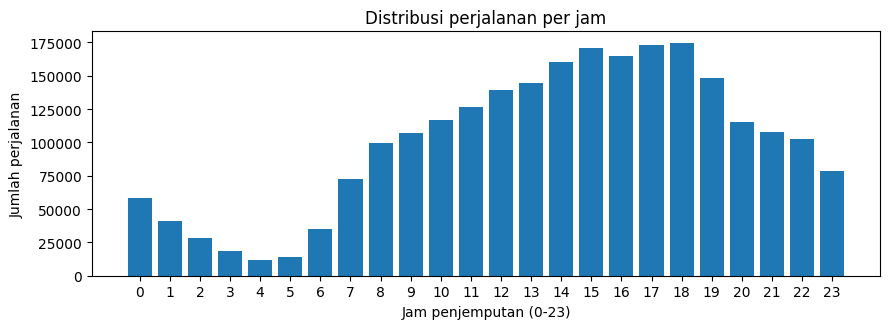

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show

Studi Kasus

1. import dan menambahkan dimensi baru

In [25]:
import matplotlib.pyplot as plt

bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

2. Perbandingan agregasi data per hari kerja dan akhir pekan

In [26]:
ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2)
    .reset_index())

print("--- 12 Baris Pertama Tabel Agregasi ---")
display(ringkas.head(12))

--- 12 Baris Pertama Tabel Agregasi ---


,akhir_pekan,jam,jumlah,rata_durasi,rata_tarif_per_menit
0,False,0,25796,12.85,2.02
1,False,1,13218,12.39,2.04
2,False,2,7547,12.05,2.03
3,False,3,4878,13.16,2.00
4,False,4,4679,13.88,2.09
5,False,5,9983,13.78,2.11
6,False,6,29390,13.32,1.86
7,False,7,63681,13.14,1.66
8,False,8,86964,13.58,1.54
9,False,9,87360,13.25,1.55


3. Grafik distribusi permintaan perjalanan (hari kerja vs akhir pekan)

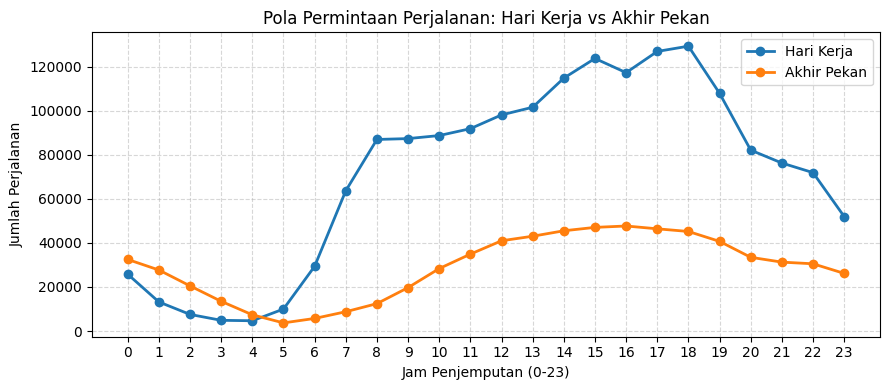

In [27]:
plt.figure(figsize=(9, 4))
for is_weekend, df_group in ringkas.groupby("akhir_pekan"):
    label = "Akhir Pekan" if is_weekend else "Hari Kerja"
    plt.plot(df_group["jam"], df_group["jumlah"],
             marker='o', linewidth=2, label=label)

plt.xlabel("Jam Penjemputan (0-23)")
plt.ylabel("Jumlah Perjalanan")
plt.title("Pola Permintaan Perjalanan: Hari Kerja vs Akhir Pekan")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/studi_kasus_permintaan.png", dpi=150)
plt.show()

4. Grafik profil profitabilitas (tarif per menit) dan durasi perjalanan per jam

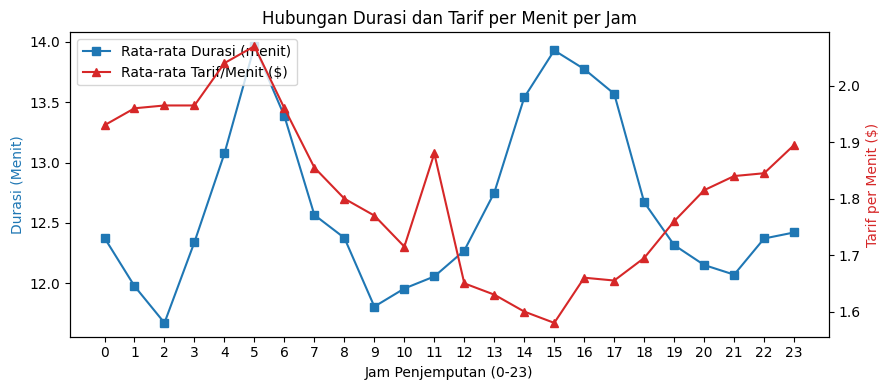

In [29]:
ringkas_jam = ringkas.groupby("jam").agg(
    rata_durasi=("rata_durasi", "mean"),
    rata_tarif_per_menit=("rata_tarif_per_menit", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

line1 = ax1.plot(
    ringkas_jam["jam"],
    ringkas_jam["rata_durasi"],
    color='tab:blue',
    marker='s',
    label='Rata-rata Durasi (menit)'
)

line2 = ax2.plot(
    ringkas_jam["jam"],
    ringkas_jam["rata_tarif_per_menit"],
    color='tab:red',
    marker='^',
    label='Rata-rata Tarif/Menit ($)'
)

ax1.set_xlabel("Jam Penjemputan (0-23)")
ax1.set_ylabel("Durasi (Menit)", color='tab:blue')
ax2.set_ylabel("Tarif per Menit ($)", color='tab:red')
plt.title("Hubungan Durasi dan Tarif per Menit per Jam")
ax1.set_xticks(range(0, 24))

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/studi_kasus_profitabilitas.png", dpi=150)
plt.show()

LATIHAN

Latihan 1

In [30]:
top5_jarak = bersih.nlargest(5, "trip_distance")

display(top5_jarak)

print("Nilai trip_distance terbesar:")
print(top5_jarak["trip_distance"].to_list())

if top5_jarak["trip_distance"].max() < 100:
    print("Komentar: Kelima perjalanan masih berada dalam batas data bersih (<100 mil), tetapi nilai yang sangat tinggi tetap perlu diperiksa karena dapat merupakan perjalanan yang tidak umum.")
else:
    print("Komentar: Terdapat nilai trip_distance yang melewati batas pembersihan sehingga perlu diperiksa kembali.")

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
2286035,2022-01-30 17:44:50,2022-01-30 19:51:08,1.0,99.46,2,200.0,0.00,206.85,126.300000,17,Sunday,True,1.638
1006243,2022-01-14 19:10:41,2022-01-14 19:26:37,1.0,99.20,1,13.0,3.45,20.75,15.933333,19,Friday,False,1.302
32345,2022-01-01 14:10:21,2022-01-01 14:24:12,1.0,98.90,1,12.5,1.00,16.80,13.850000,14,Saturday,True,1.213
518323,2022-01-08 14:15:10,2022-01-08 14:29:28,1.0,98.40,1,12.0,3.05,18.35,14.300000,14,Saturday,True,1.283
895906,2022-01-13 15:41:09,2022-01-13 18:10:10,1.0,98.15,1,270.0,25.00,303.10,149.016667,15,Thursday,False,2.034


Nilai trip_distance terbesar:
[99.46, 99.2, 98.9, 98.4, 98.15]
Komentar: Kelima perjalanan masih berada dalam batas data bersih (<100 mil), tetapi nilai yang sangat tinggi tetap perlu diperiksa karena dapat merupakan perjalanan yang tidak umum.


Latihan 2

In [31]:
import gc

gc.collect()

hasil_100k = ukur(
    "agregasi chunking 100000",
    lambda: agregasi_bertahap(CSV, ukuran_chunk=100_000)
)

gc.collect()

hasil_1m = ukur(
    "agregasi chunking 1000000",
    lambda: agregasi_bertahap(CSV, ukuran_chunk=1_000_000)
)

hasil_chunking = pd.DataFrame(catatan[-2:])

display(
    hasil_chunking[
        ["langkah", "detik", "delta_rss_mb"]
    ]
)

print("Trade-off: chunksize lebih kecil cenderung menggunakan memori lebih rendah tetapi membutuhkan lebih banyak iterasi, sedangkan chunksize lebih besar cenderung mengurangi overhead iterasi namun membutuhkan memori lebih besar.")

[agregasi chunking 100000]  3.45 s | RSS +4.1 MB
[agregasi chunking 1000000]  2.08 s | RSS +18.7 MB


,langkah,detik,delta_rss_mb
0,agregasi chunking 100000,3.45,4.1
1,agregasi chunking 1000000,2.08,18.7


Trade-off: chunksize lebih kecil cenderung menggunakan memori lebih rendah tetapi membutuhkan lebih banyak iterasi, sedangkan chunksize lebih besar cenderung mengurangi overhead iterasi namun membutuhkan memori lebih besar.


Latihan 3

In [32]:
bersih["persen_tip"] = (
    bersih["tip_amount"]
    .div(bersih["fare_amount"].mask(bersih["fare_amount"] == 0))
    .mul(100)
)

rata_persen_tip = (
    bersih
    .groupby("payment_type", observed=True)
    .agg(
        jumlah_transaksi=("persen_tip", "count"),
        rata_persen_tip=("persen_tip", "mean")
    )
    .round(2)
    .reset_index()
)

display(rata_persen_tip)

print(
    "Dugaan: perbedaan rata-rata persen tip antar payment_type "
    "dapat menunjukkan adanya perbedaan perilaku pemberian tip "
    "berdasarkan metode pembayaran yang digunakan."
)

,payment_type,jumlah_transaksi,rata_persen_tip
0,0,66995,20.55
1,1,1853288,27.43
2,2,479806,0.00
3,3,6551,0.01
4,4,2517,0.00
5,5,1,0.00


Dugaan: perbedaan rata-rata persen tip antar payment_type dapat menunjukkan adanya perbedaan perilaku pemberian tip berdasarkan metode pembayaran yang digunakan.


Latihan 4

In [33]:
import os

path_snappy = os.path.join(DIR_SIMPAN, "bersih_snappy.parquet")
path_gzip = os.path.join(DIR_SIMPAN, "bersih_gzip.parquet")

ukur(
    "tulis Parquet Snappy",
    lambda: bersih.to_parquet(
        path_snappy,
        index=False,
        compression="snappy"
    )
)

ukur(
    "tulis Parquet Gzip",
    lambda: bersih.to_parquet(
        path_gzip,
        index=False,
        compression="gzip"
    )
)

ukuran_snappy = os.path.getsize(path_snappy) / (1024 ** 2)
ukuran_gzip = os.path.getsize(path_gzip) / (1024 ** 2)

hasil_parquet = pd.DataFrame(catatan[-2:]).copy()

hasil_parquet["ukuran_mb"] = [
    ukuran_snappy,
    ukuran_gzip
]

hasil_parquet = hasil_parquet[
    ["langkah", "detik", "delta_rss_mb", "ukuran_mb"]
]

display(hasil_parquet)

if ukuran_gzip < ukuran_snappy:
    print("Gzip menghasilkan ukuran file yang lebih kecil dibandingkan Snappy.")
else:
    print("Snappy menghasilkan ukuran file yang lebih kecil atau sama dibandingkan Gzip.")

[tulis Parquet Snappy]  1.78 s | RSS +60.7 MB
[tulis Parquet Gzip]  25.63 s | RSS -9.0 MB


,langkah,detik,delta_rss_mb,ukuran_mb
0,tulis Parquet Snappy,1.78,60.7,51.459267
1,tulis Parquet Gzip,25.63,-9.0,41.112990


Gzip menghasilkan ukuran file yang lebih kecil dibandingkan Snappy.


Latihan 5

In [38]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("BD-P01-J9-Spark-SQL")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

agregasi_pandas = (
    bersih
    .assign(jam=bersih["tpep_pickup_datetime"].dt.hour)
    .groupby("jam")
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_jarak=("trip_distance", "mean"),
        rata_durasi=("durasi_menit", "mean"),
        rata_tarif=("total_amount", "mean")
    )
    .round(2)
    .reset_index()
)

sdf = spark.read.parquet(PATH)

sdf_bersih = (
    sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime").cast("long")
                   - F.unix_timestamp("tpep_pickup_datetime").cast("long")
        ) / 60
    )
    .filter(
        (F.col("trip_distance") > 0) &
        (F.col("trip_distance") < 100)
    )
    .filter(
        (F.col("durasi_menit") >= 1) &
        (F.col("durasi_menit") <= 180)
    )
    .filter(
        F.col("total_amount") > 0
    )
)

sdf_bersih.createOrReplaceTempView("trips_bersih")

hasil_sql = spark.sql("""
    SELECT
        HOUR(tpep_pickup_datetime) AS jam,
        COUNT(*) AS jumlah_perjalanan,
        ROUND(AVG(trip_distance), 2) AS rata_jarak,
        ROUND(AVG(durasi_menit), 2) AS rata_durasi,
        ROUND(AVG(total_amount), 2) AS rata_tarif
    FROM trips_bersih
    GROUP BY HOUR(tpep_pickup_datetime)
    ORDER BY jam
""")

hasil_spark = hasil_sql.toPandas()

perbandingan = (
    agregasi_pandas[["jam", "jumlah_perjalanan"]]
    .merge(
        hasil_spark[["jam", "jumlah_perjalanan"]],
        on="jam",
        suffixes=("_pandas", "_spark_sql")
    )
)

perbandingan["selisih"] = (
    perbandingan["jumlah_perjalanan_pandas"]
    - perbandingan["jumlah_perjalanan_spark_sql"]
)

display(perbandingan)

selisih_maksimum = perbandingan["selisih"].abs().max()

print("Selisih maksimum:", selisih_maksimum)

if selisih_maksimum == 0:
    print("Hasil konsisten: jumlah perjalanan Pandas dan Spark SQL sama pada seluruh jam.")
else:
    print("Terdapat perbedaan hasil. Perbedaan dapat berasal dari perbedaan proses cleaning, pembentukan kolom jam, atau data yang digunakan.")

,jam,jumlah_perjalanan_pandas,jumlah_perjalanan_spark_sql,selisih
0,0,58298,58298,0
1,1,40929,40929,0
2,2,28049,28049,0
3,3,18382,18382,0
4,4,12055,12055,0
5,5,13693,13693,0
6,6,35115,35115,0
7,7,72453,72453,0
8,8,99413,99413,0
9,9,107081,107081,0


Selisih maksimum: 0
Hasil konsisten: jumlah perjalanan Pandas dan Spark SQL sama pada seluruh jam.
